In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/letter-recognition.data", header=None)

# Assign column names
columns = ["letter"] + [f"x{i}" for i in range(1, 17)]
data.columns = columns

print(data.head())

  letter  x1  x2  x3  x4  x5  x6  x7  x8  x9  x10  x11  x12  x13  x14  x15  \
0      T   2   8   3   5   1   8  13   0   6    6   10    8    0    8    0   
1      I   5  12   3   7   2  10   5   5   4   13    3    9    2    8    4   
2      D   4  11   6   8   6  10   6   2   6   10    3    7    3    7    3   
3      N   7  11   6   6   3   5   9   4   6    4    4   10    6   10    2   
4      G   2   1   3   1   1   8   6   6   6    6    5    9    1    7    5   

   x16  
0    8  
1   10  
2    9  
3    8  
4   10  


In [3]:
X = data.drop("letter", axis=1)
y = data["letter"]

In [4]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)  # A-Z

Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = models.Sequential([
    layers.Input(shape=(16,)),   # 16 features
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(26, activation='softmax')   # 26 letters
])

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5110 - loss: 1.7471 - val_accuracy: 0.6963 - val_loss: 1.0402
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7475 - loss: 0.8572 - val_accuracy: 0.7847 - val_loss: 0.7677
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8079 - loss: 0.6637 - val_accuracy: 0.8128 - val_loss: 0.6339
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8361 - loss: 0.5544 - val_accuracy: 0.8391 - val_loss: 0.5544
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8573 - loss: 0.4840 - val_accuracy: 0.8494 - val_loss: 0.4967
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8719 - loss: 0.4335 - val_accuracy: 0.8725 - val_loss: 0.4552
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8842 - loss: 0.3925 - val_accuracy: 0.8791 - val_loss: 0.4115
Epoch 8/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8920 - loss: 0.3599 - val_accuracy: 

In [10]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9405 - loss: 0.2068
Test Loss: 0.20678138732910156
Test Accuracy: 0.940500020980835


In [11]:
y_pred = model.predict(X_test)

predicted_labels = np.argmax(y_pred, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", y_test[:10])

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [19 11  0  4 16  4 14 16  6 14]
Actual: [19 11  0  4 16  4 14 16  6 14]


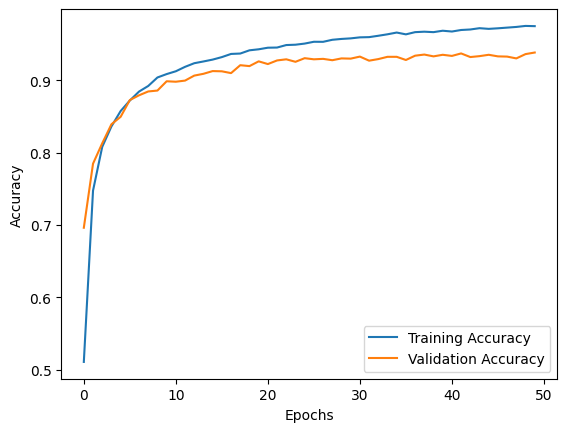

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
new_letter = [[3,5,2,4,6,8,1,0,5,3,2,7,1,2,0,1]]  # 16 features

# Scale
new_letter_scaled = scaler.transform(new_letter)

# Predict
prediction = model.predict(new_letter_scaled)

predicted_class = np.argmax(prediction)
print("Predicted Letter:", encoder.inverse_transform([predicted_class]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Letter: ['A']
